# Hala Mohammed 238119

### Import necessary libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.model_selection import RandomizedSearchCV
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

## Import dataset

In [2]:
dataset="HealthcareRiskFactors.csv"
df = pd.read_csv(dataset)
df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


In [3]:
df.shape
#this shows the dataset contains:
#30k instances 
#20 features

(30000, 20)

In [4]:
df.nunique()

Age                     80
Gender                   2
Medical Condition        7
Glucose              11097
Blood Pressure        8259
BMI                   3097
Oxygen Saturation     2267
LengthOfStay            19
Cholesterol          12021
Triglycerides        14840
HbA1c                  770
Smoking                  2
Alcohol                  2
Physical Activity     1154
Diet Score            1103
Family History           2
Stress Level          1300
Sleep Hours            745
random_notes             4
noise_col            30000
dtype: int64

In [5]:
df.dtypes

Age                  float64
Gender                object
Medical Condition     object
Glucose              float64
Blood Pressure       float64
BMI                  float64
Oxygen Saturation    float64
LengthOfStay           int64
Cholesterol          float64
Triglycerides        float64
HbA1c                float64
Smoking                int64
Alcohol                int64
Physical Activity    float64
Diet Score           float64
Family History         int64
Stress Level         float64
Sleep Hours          float64
random_notes          object
noise_col            float64
dtype: object

In [6]:
df.describe()

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,noise_col
count,25500.000000,25500.000000,25500.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,54.616784,123.622179,140.455337,28.476155,94.954992,4.414133,213.033891,176.837375,6.294377,0.279767,0.238533,3.803214,4.029654,0.439433,5.917312,6.229836,-0.517010
std,15.973618,41.576943,21.077933,5.728804,3.736202,2.761536,33.519757,48.812827,1.320269,0.448892,0.426194,2.011729,1.817165,0.496326,2.225057,1.187669,100.076959
min,10.000000,20.320000,74.240000,7.670000,67.510000,1.000000,95.730000,-22.480000,3.280000,0.000000,0.000000,-3.680000,-1.750000,0.000000,-2.440000,1.590000,-412.169596
25%,45.000000,96.280000,125.140000,24.590000,93.000000,3.000000,189.500000,141.280000,5.330000,0.000000,0.000000,2.350000,2.770000,0.000000,4.370000,5.410000,-68.270749
50%,55.000000,110.500000,138.320000,28.050000,95.300000,4.000000,211.835000,173.365000,5.970000,0.000000,0.000000,3.590000,3.790000,0.000000,5.900000,6.230000,-0.510742
75%,66.000000,136.610000,153.790000,31.810000,97.380000,5.000000,235.310000,208.630000,6.920000,1.000000,0.000000,5.060000,5.020000,1.000000,7.440000,7.050000,66.811399
max,89.000000,318.510000,226.380000,56.850000,110.070000,19.000000,358.370000,421.510000,12.360000,1.000000,1.000000,12.410000,12.060000,1.000000,15.450000,10.350000,467.894910


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

### Checking null values

In [8]:
df.isnull().sum()

Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64

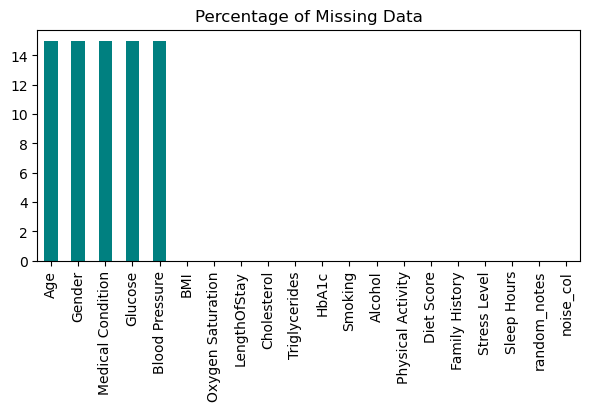

In [9]:
missing=df.isnull().mean()*100
missing.plot(kind='bar',figsize=(7,3) ,title='Percentage of Missing Data',color='teal')
plt.show()
#this shows that features (Age,Gender,Medical Condition,Glucose,Blood Pressure) each contain around 15% of missing values

In [10]:
df['Medical Condition'].unique()
#there are the 7 classes

array(['Diabetes', 'Healthy', 'Asthma', 'Obesity', 'Hypertension',
       'Cancer', nan, 'Arthritis'], dtype=object)

##### Drop nulls in target column

In [11]:
#drop nulls, as we cannot impute values in target class
df1=df.dropna(subset=['Medical Condition'])

In [12]:
df1['Medical Condition'].unique()

array(['Diabetes', 'Healthy', 'Asthma', 'Obesity', 'Hypertension',
       'Cancer', 'Arthritis'], dtype=object)

In [13]:
df1.isnull().sum()

Age                  3821
Gender               3794
Medical Condition       0
Glucose              3788
Blood Pressure       3800
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64

In [14]:
df1.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


In [15]:
#drop unnecessary columns
df2=df1.drop(columns=['random_notes','noise_col'])
df2.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


In [16]:
df2.duplicated().sum()

np.int64(0)

In [17]:
#Age,Gender,Glucose,Blood Pressure are the 4 features that still have missing values after dropping the nulls in the target column
#checking whther missingess is related to the target class or no

df2['is_missing_any'] = df2[['Age','Gender','Glucose','Blood Pressure']].isnull().any(axis=1).astype(int)
(df2.groupby('Medical Condition')['is_missing_any'].mean()*100).sort_values(ascending=False)

#this shows that half of the patients in each class are missing at least one of those 4 features
#missingness is almost the same, slightly different, showing that none is strongly dependent on a class

Medical Condition
Cancer          50.567261
Arthritis       48.719376
Asthma          47.913598
Obesity         47.705471
Hypertension    47.359551
Healthy         47.285291
Diabetes        47.078074
Name: is_missing_any, dtype: float64

In [18]:
df2 = df2.drop(columns=['is_missing_any'])

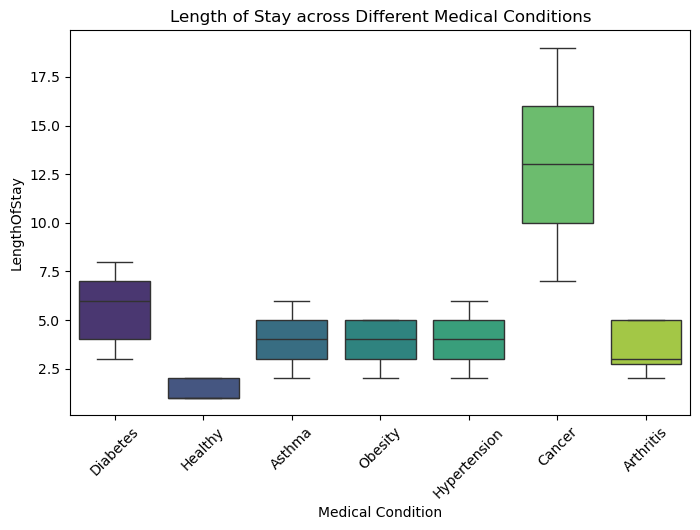

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df2, x='Medical Condition', y='LengthOfStay', palette='viridis')
plt.title("Length of Stay across Different Medical Conditions")
plt.xticks(rotation=45)
plt.show()

in real-life scenarios, we dont know length of stay before diagnosis

according to the visualizaiton, cancer cases have much longer stays (7–17 days) compared to other conditions (1–6 days), this suggests that LengthOfStay is a consequence of the medical condition, not a cause

basically, this feature is an outcome, not a predictor for medical condition, therefore, we should not use this column as an input feature to avoid data leakage, as it reflects inofmrartion that would only be known after diagnosis

In [20]:
df2 = df2.drop(columns=['LengthOfStay'])
df2.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


#### inspecting target class

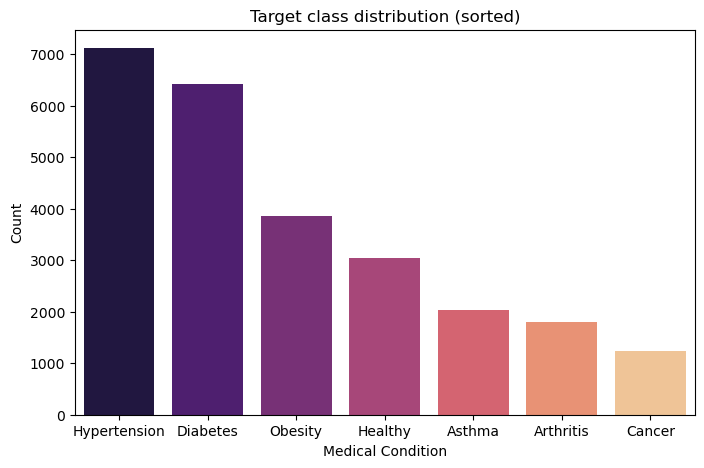

Medical Condition
Hypertension    7120
Diabetes        6417
Obesity         3857
Healthy         3039
Asthma          2037
Arthritis       1796
Cancer          1234
Name: count, dtype: int64

In [21]:
countTarget=df2['Medical Condition'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=countTarget.index, y=countTarget.values, palette="magma")
plt.title("Target class distribution (sorted)")
plt.ylabel("Count")
plt.xlabel("Medical Condition")
plt.show()
df2['Medical Condition'].value_counts() 
#this clearly shows that the target class has some imbalance, as the highest class has 7120, where the lowest has 1234

## Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df2, test_size=0.2, random_state=42, stratify=df2['Medical Condition'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (20400, 17)
Test shape: (5100, 17)


In [23]:
numerical_columns = ['Age', 'Glucose', 'Blood Pressure']
categorical_columns = ['Gender']

In [24]:
#applying imputer on the train data
median_imputer = SimpleImputer(strategy='median')
train_df[numerical_columns] = median_imputer.fit_transform(train_df[numerical_columns])

freq_imputer = SimpleImputer(strategy='most_frequent')
train_df[categorical_columns] = freq_imputer.fit_transform(train_df[categorical_columns])

In [25]:
#applying imputer on the test data
test_df[numerical_columns] = median_imputer.transform(test_df[numerical_columns])
test_df[categorical_columns] = freq_imputer.transform(test_df[categorical_columns])

In [26]:
train_df.isnull().sum()
test_df.isnull().sum()

Age                  0
Gender               0
Medical Condition    0
Glucose              0
Blood Pressure       0
BMI                  0
Oxygen Saturation    0
Cholesterol          0
Triglycerides        0
HbA1c                0
Smoking              0
Alcohol              0
Physical Activity    0
Diet Score           0
Family History       0
Stress Level         0
Sleep Hours          0
dtype: int64

In [27]:
train_df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
8949,55.0,Male,Obesity,85.09,158.17,34.90,96.95,210.16,156.81,4.80,1,1,2.15,3.77,0,6.75,4.93
8002,78.0,Female,Hypertension,74.35,123.24,27.16,92.20,262.73,255.94,7.05,1,1,2.76,3.99,1,8.47,7.32
22946,47.0,Male,Obesity,129.66,117.48,30.69,93.11,209.10,183.18,6.53,0,0,2.30,3.18,0,5.27,6.48
9473,46.0,Male,Hypertension,115.43,164.53,27.08,98.26,291.11,161.43,5.88,0,1,3.09,3.67,1,5.31,5.95
28551,41.0,Female,Obesity,71.23,132.24,33.42,92.05,201.50,212.28,5.64,1,0,2.61,2.08,1,1.92,6.74


In [28]:
train_df.shape

(20400, 17)

#### inspecting target class in the train set 

as expected, imbalance still remains, max class went from 7120 to 5634, and lowest class from 1234 to 961

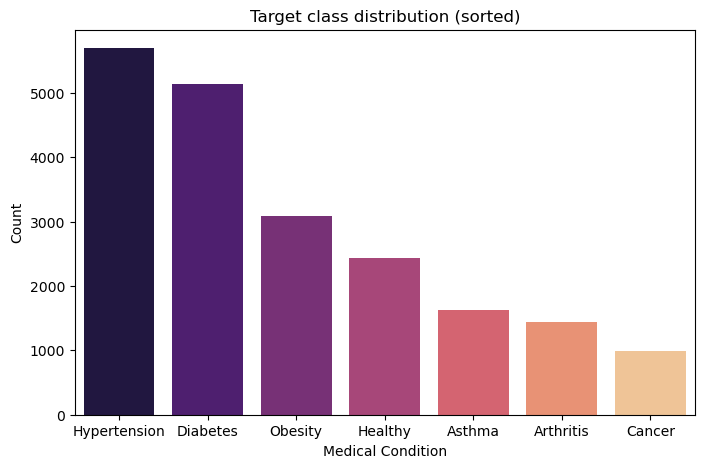

Medical Condition
Hypertension    5696
Diabetes        5133
Obesity         3086
Healthy         2431
Asthma          1630
Arthritis       1437
Cancer           987
Name: count, dtype: int64

In [29]:
countTarget=train_df['Medical Condition'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=countTarget.index, y=countTarget.values, palette="magma")
plt.title("Target class distribution (sorted)")
plt.ylabel("Count")
plt.xlabel("Medical Condition")
plt.show()
train_df['Medical Condition'].value_counts() 

# Data Visualizaitons

## Visualizing categorical/binary features

according to the barcharts, we can observe that the count of genders (F/M) are approximately close, but there is some difference as females are more

family medical history is also the same case as gender in terms of balance, as the majority of patients do not have a family medical history

but for features like smoking and alcohol, the difference may vary a lot, showing that the majority of patients do not smoke or consume alcohol

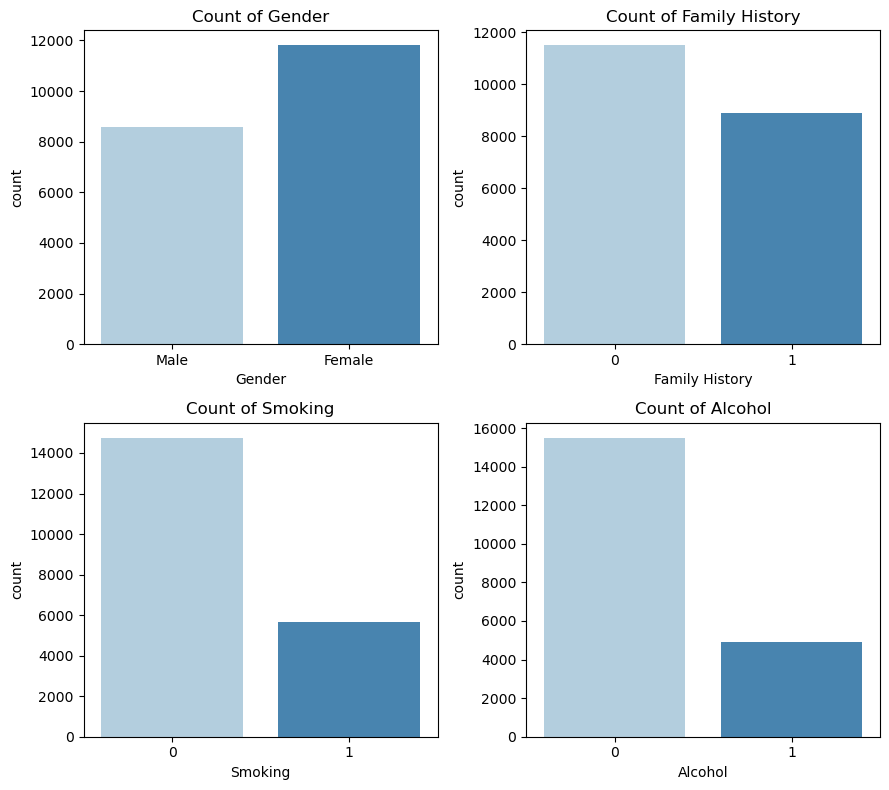

In [30]:
categorical_columns = ['Gender','Family History','Smoking', 'Alcohol',]

plt.figure(figsize=(9, 8))  
for i, col in enumerate(categorical_columns):
    plt.subplot(2, 2, i + 1)  # (rows, cols, position)
    sns.countplot(data=train_df, x=col, palette='Blues')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel("count")

plt.tight_layout() 
plt.show()

## Visualizing Numeical features

most of the features represent a uniform distribution, they are symmetric and centered such as:
BMI,Blood Pressure,Cholesterol,Triglycerides,Physical Activity, Diet Score, Stress Level, and Sleep Hours

while "glucose" and "HbA1c" are more rightly skewed

in glucose, the peak is around 100, but then it extends to above 200 indicating a substantial number of patients may potentially be diabetic

for age, it shows a higher peak for older patients, while shorter for young, suggesting that a higher number of patients are old between 45-75  

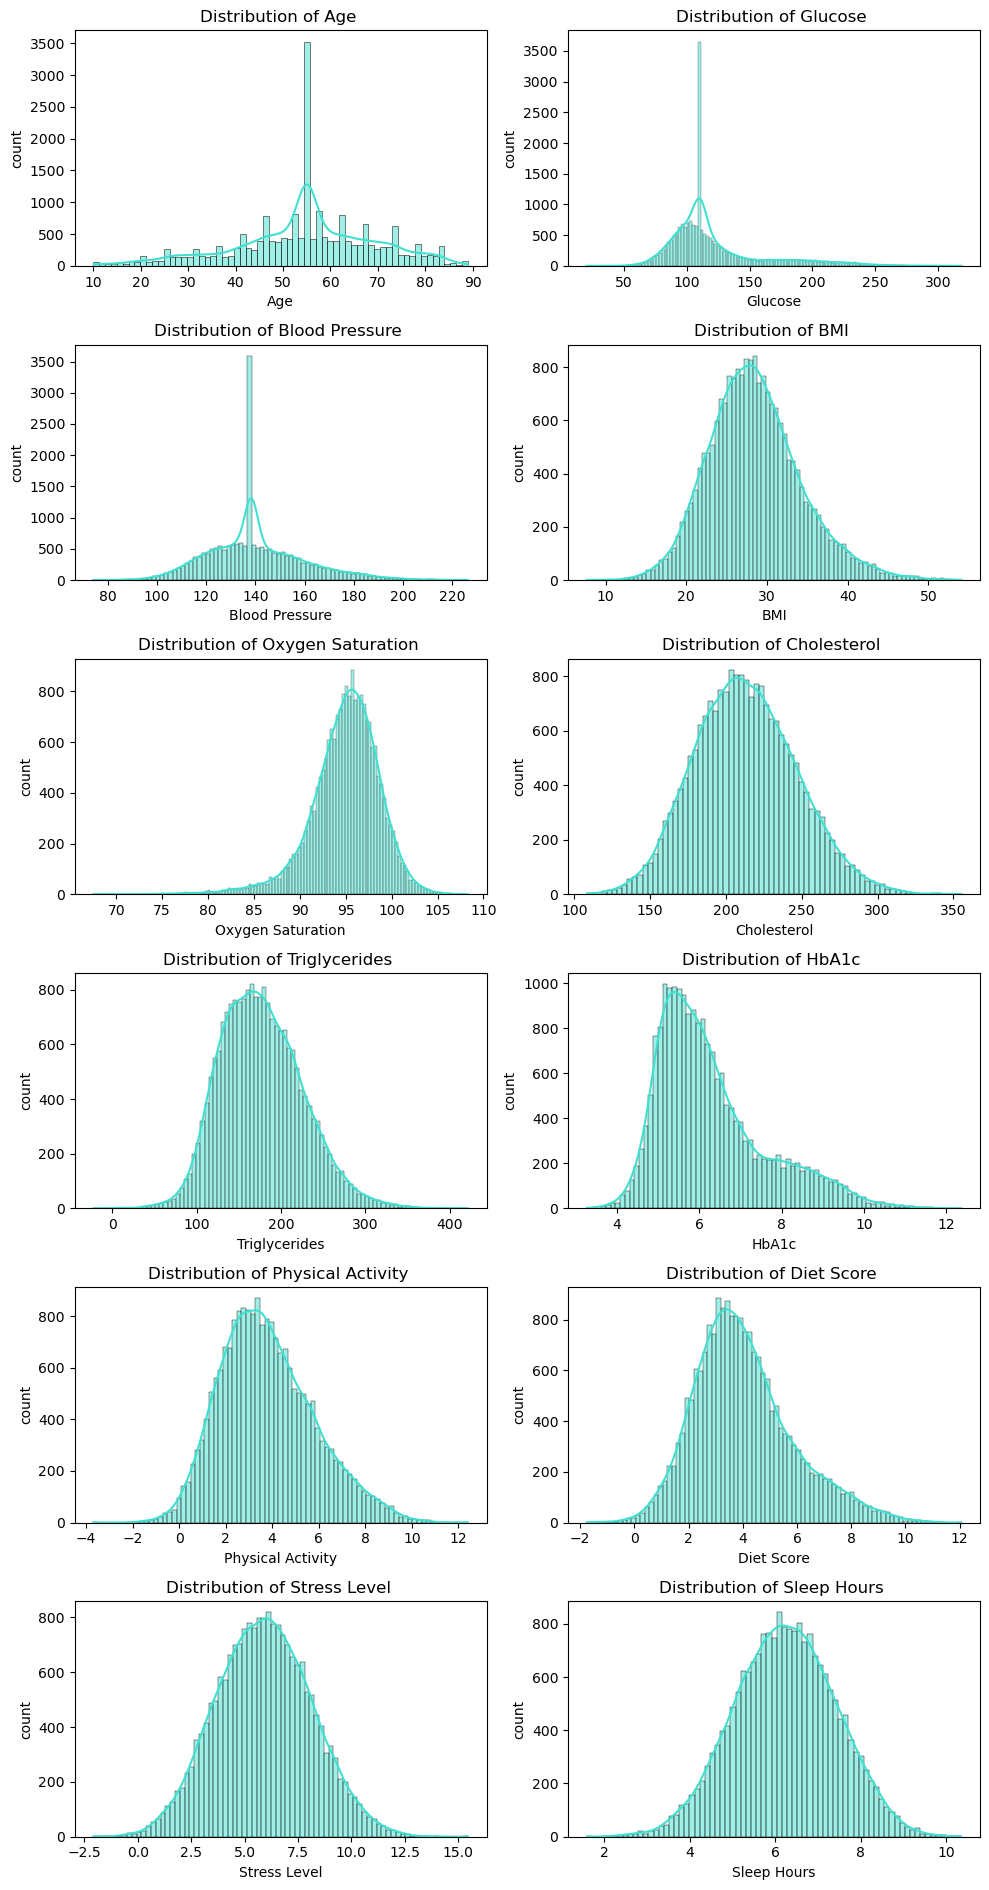

In [31]:
numerical_columns = ['Age','Glucose','Blood Pressure','BMI','Oxygen Saturation','Cholesterol','Triglycerides','HbA1c','Physical Activity','Diet Score','Stress Level','Sleep Hours']
plt.figure(figsize=(10, 19))  
               
for i,col in enumerate(numerical_columns):
    plt.subplot(6,2,i+1)
    sns.histplot(train_df[col],kde=True,color='turquoise')
    plt.title(f"Distribution of {col} ")
    plt.xlabel(col)
    plt.ylabel("count")
    
plt.tight_layout() 
plt.show()

## Visualizing features VS target column

#### categorical VS target column

from the visualizations plotted
we can see that genders doesnt affect a specific medical conditions, especially that both genders are balanced, this suggests that no specific gender aligns with a specific mdeical condition, so gender is not an influential factor in this case

for family history, we can conclude that this fetaure plays a role in predicting the chance of a patient getting a specific disease, especially in most patients who have family medical history in diabetes and hypertension appear to be more prone to be diagnosed with it

for alcohol and smoking, we have seen previously that it is imbalanced such that most patients are non-smokers and non-drinkers, however, we can observe that most highest number of smokers and alcohol drinkers are more likely to be diagnosed with hypertension &diabetes

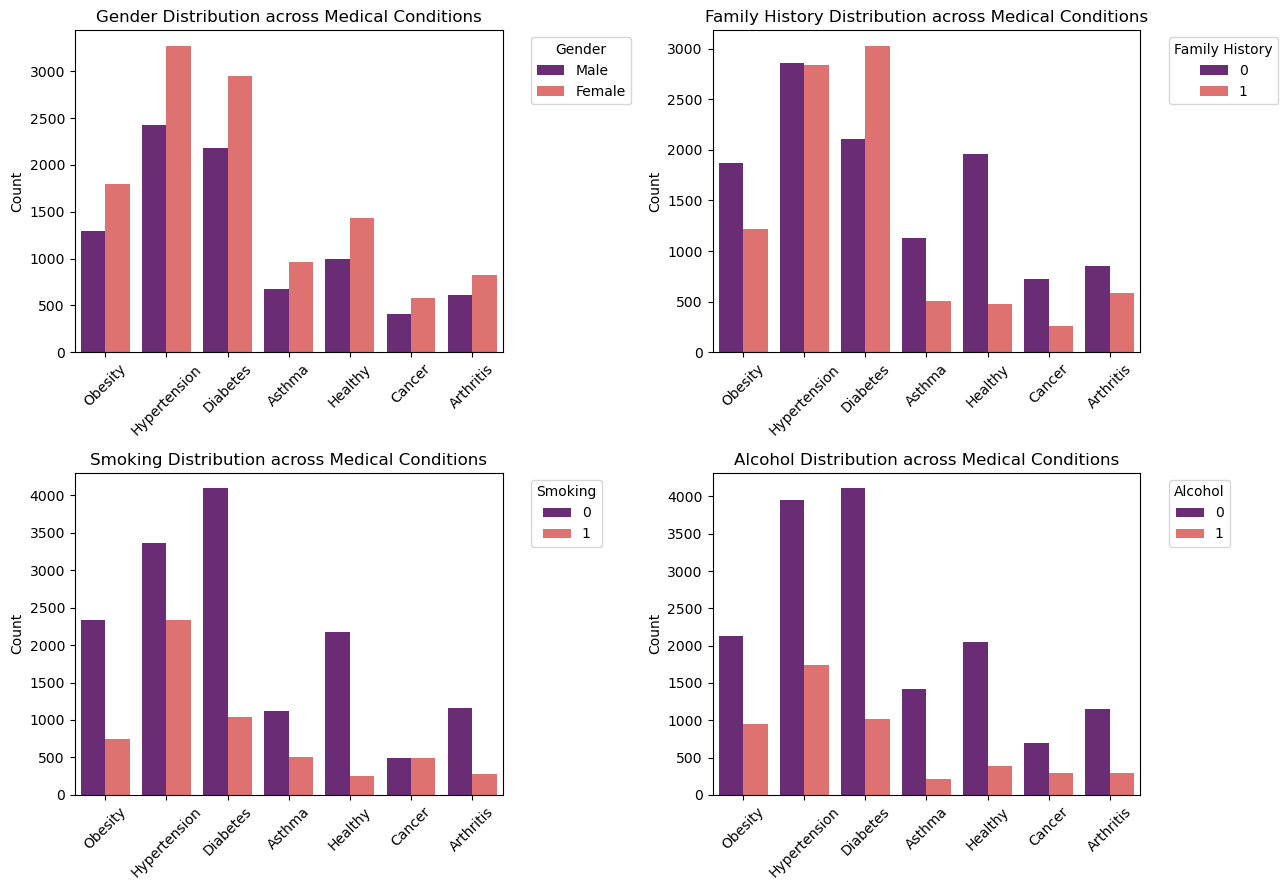

In [32]:
categorical_features = ['Gender','Family History','Smoking', 'Alcohol']  
plt.figure(figsize=(13, 9))  

for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(x='Medical Condition',hue=col, data=train_df, palette='magma')
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution across Medical Conditions')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout()
plt.show()


#### numerical VS target column
according to the boxplot visualizations

its clearly seen that outliers occur in many features

we can also see negative values (likely errors)

there seems to be noticeale pattern, where some features tend to show clear patterns with medical conditions, indicating that certain fetaures tend to be associated with specific medical conditions,
examples:

patients with high level of glucose or HbA1C tend to correspond to diabetes

patients with high BMI or high blood pressure tend to correspond to obesity or hypertension

patients with a good diet tend to be more healthy 

asthma cases only occurs in ages between 10 and 60 only, mostly(average) are between the 20s and 50s

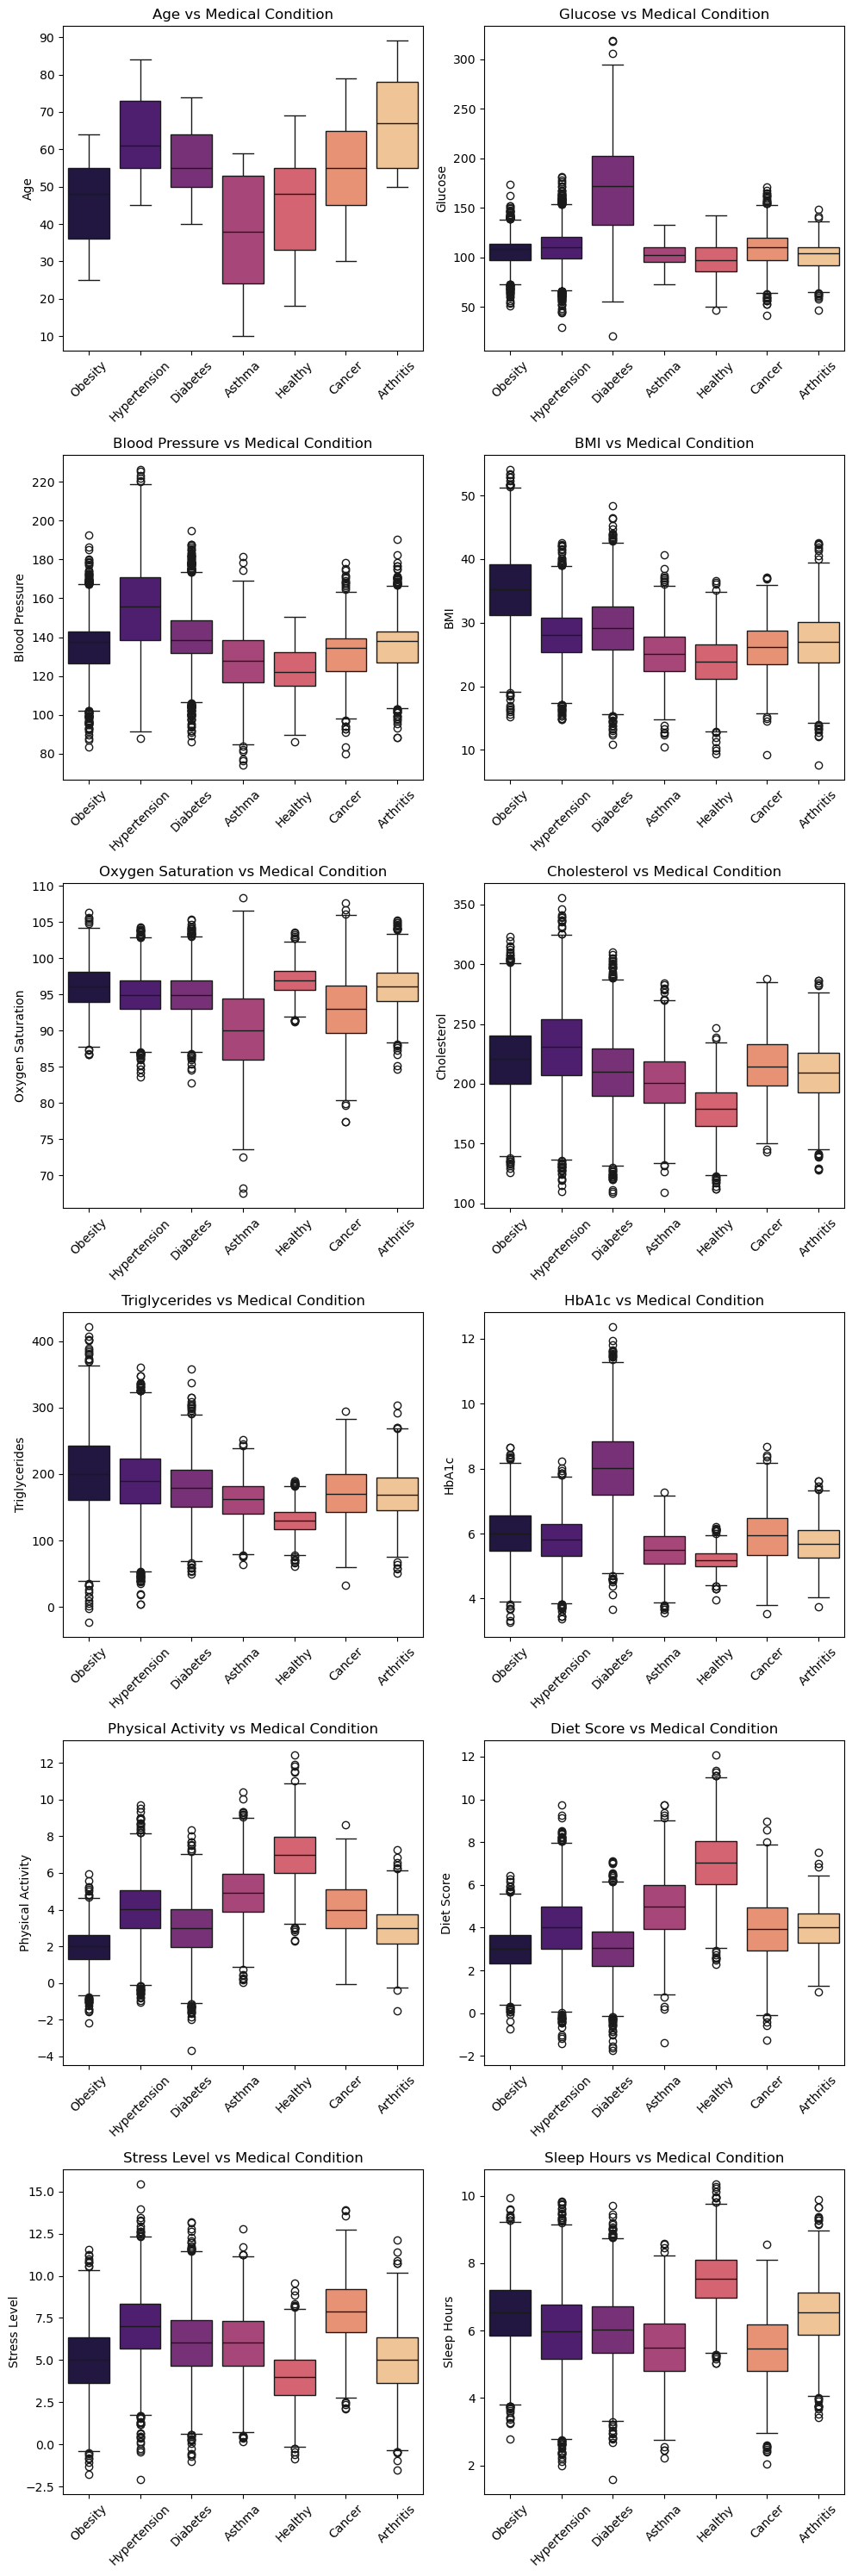

In [33]:
numerical_columns = ['Age','Glucose','Blood Pressure','BMI','Oxygen Saturation','Cholesterol','Triglycerides','HbA1c','Physical Activity','Diet Score','Stress Level','Sleep Hours']

plt.figure(figsize=(10, 30))

for i,col in enumerate(numerical_columns):
    plt.subplot(6, 2, i+1) 
    sns.boxplot(x='Medical Condition', y=col, data=train_df, palette='magma')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Medical Condition')
    plt.xlabel('')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Handling outliers

as we have seen negative values previsouly in box plots, we examined the minimum and maximum values of all numeric features 

This revealed negative values in several features like Triglycerides, Physical Activity, Diet Score, and Stress Level), as well as oxygen saturation values above 100%, which represent biologically impossible readings

therefore we drop these error values to ensure data integrity prior to model training

first, we print min and max for all numeric features to detect where the unrealistic entries occur, to observe a shortlist of suspicious variables to examine visually

we can observe a suspicious value '108' for oxygen saturation (its unrealistic to be above 100)

In [34]:
numeric_columns =  ['Age','Glucose','Blood Pressure','BMI','Oxygen Saturation','Cholesterol','Triglycerides','HbA1c','Physical Activity','Diet Score','Stress Level','Sleep Hours']

for col in numeric_columns:
    print(f"{col:20} | Min: {train_df[col].min():8}    | Max: {train_df[col].max():8}")

Age                  | Min:     10.0    | Max:     89.0
Glucose              | Min:    20.32    | Max:   318.51
Blood Pressure       | Min:    74.24    | Max:   226.38
BMI                  | Min:     7.67    | Max:    54.07
Oxygen Saturation    | Min:    67.51    | Max:    108.3
Cholesterol          | Min:   108.27    | Max:   355.27
Triglycerides        | Min:   -22.48    | Max:   421.51
HbA1c                | Min:     3.28    | Max:    12.36
Physical Activity    | Min:    -3.68    | Max:    12.41
Diet Score           | Min:    -1.75    | Max:    12.06
Stress Level         | Min:    -2.07    | Max:    15.45
Sleep Hours          | Min:     1.59    | Max:    10.35


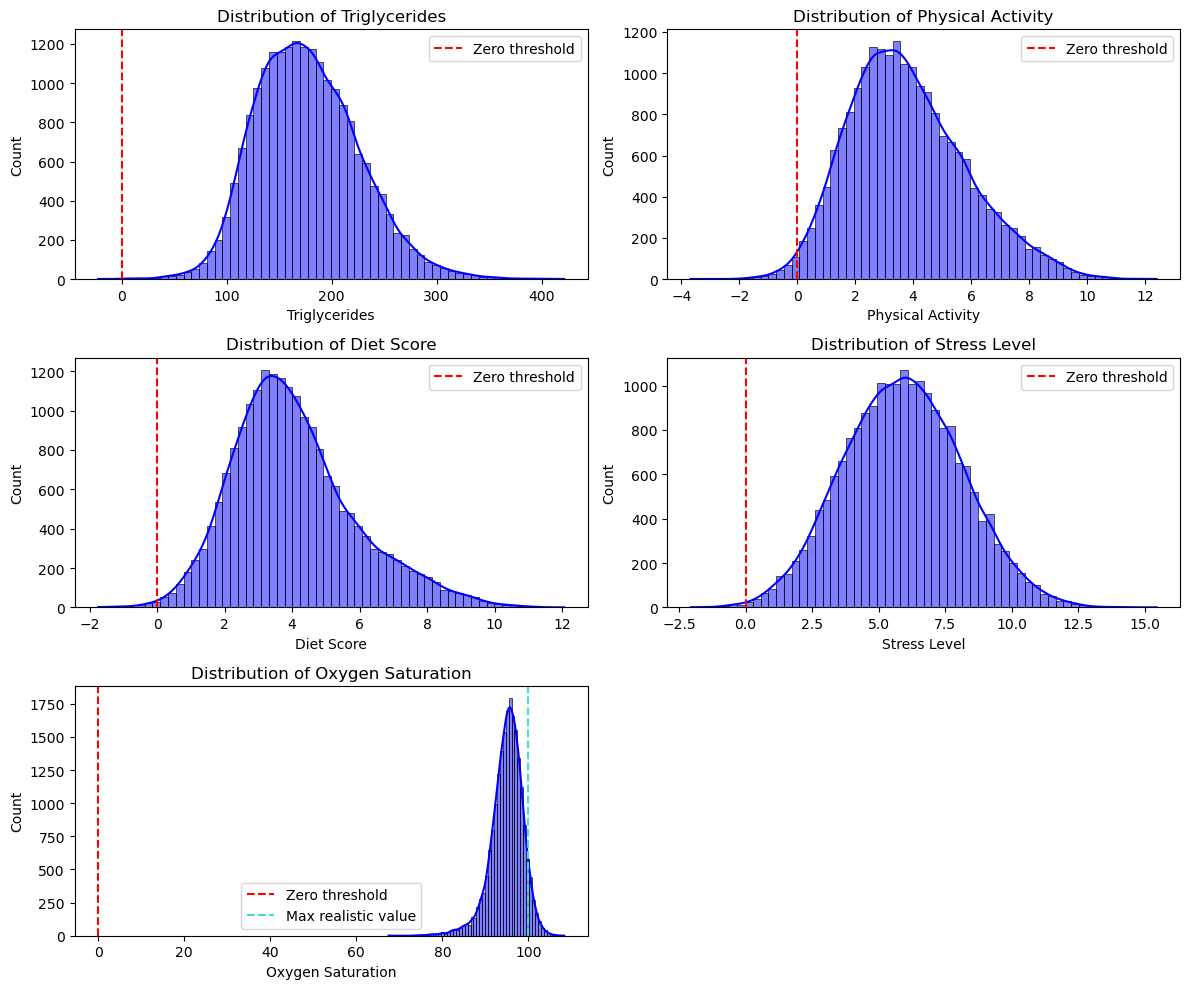

In [35]:
outlier_columns=['Triglycerides', 'Physical Activity', 'Diet Score', 'Stress Level', 'Oxygen Saturation']
plt.figure(figsize=(12, 10))
for i,col in enumerate(outlier_columns):
    plt.subplot(3,2, i+1) 
    sns.histplot(train_df[col], bins=60, kde=True,color='blue')
    plt.title(f"Distribution of {col}")
    plt.axvline(0, color='red', linestyle='--', label='Zero threshold')
    if col == 'Oxygen Saturation':
        plt.axvline(100, color='turquoise', linestyle='--', label='Max realistic value')
    plt.legend()
    
plt.tight_layout()
plt.show()

#### cleaning negative columns

In [36]:
negative_columns=["Triglycerides","Physical Activity","Diet Score","Stress Level"]
print("Negative value counts before dropping:")
for col in negative_columns:
    print(f"{col:20}: {(train_df[col] < 0).sum()}")

train_df = train_df[(train_df[negative_columns] >= 0).all(axis=1)]

print("\nAfter dropping negative values:")
for col in numeric_columns:
    print(f"{col:20} | Min: {train_df[col].min():8}    | Max: {train_df[col].max():8}")


Negative value counts before dropping:
Triglycerides       : 2
Physical Activity   : 235
Diet Score          : 65
Stress Level        : 41

After dropping negative values:
Age                  | Min:     10.0    | Max:     89.0
Glucose              | Min:    20.32    | Max:   318.51
Blood Pressure       | Min:    74.24    | Max:   226.38
BMI                  | Min:     7.67    | Max:    54.07
Oxygen Saturation    | Min:    67.51    | Max:    108.3
Cholesterol          | Min:   108.27    | Max:   355.27
Triglycerides        | Min:     1.14    | Max:   406.64
HbA1c                | Min:     3.28    | Max:    12.36
Physical Activity    | Min:      0.0    | Max:    12.41
Diet Score           | Min:     -0.0    | Max:    12.06
Stress Level         | Min:     -0.0    | Max:    15.45
Sleep Hours          | Min:     1.59    | Max:    10.35


In [37]:
#replacing all -0.0 with 0.0 in numeric columns
train_df[negative_columns] = train_df[negative_columns].replace(-0.0, 0.0)

for col in numeric_columns:
    print(f"{col:20} | Min: {train_df[col].min():8}    | Max: {train_df[col].max():8}")

Age                  | Min:     10.0    | Max:     89.0
Glucose              | Min:    20.32    | Max:   318.51
Blood Pressure       | Min:    74.24    | Max:   226.38
BMI                  | Min:     7.67    | Max:    54.07
Oxygen Saturation    | Min:    67.51    | Max:    108.3
Cholesterol          | Min:   108.27    | Max:   355.27
Triglycerides        | Min:     1.14    | Max:   406.64
HbA1c                | Min:     3.28    | Max:    12.36
Physical Activity    | Min:      0.0    | Max:    12.41
Diet Score           | Min:      0.0    | Max:    12.06
Stress Level         | Min:      0.0    | Max:    15.45
Sleep Hours          | Min:     1.59    | Max:    10.35


#### cleaning "Oxygen Saturation" column

In [38]:
print("Values above 100 for oxygen saturation: ",(train_df["Oxygen Saturation"]>100).sum())

os = train_df["Oxygen Saturation"]
os_above_100 = os[os > 100].value_counts().sort_index()

print("\nCounts of each Oxygen Saturation value > 100:")
print(os_above_100)


Values above 100 for oxygen saturation:  1223

Counts of each Oxygen Saturation value > 100:
Oxygen Saturation
100.01    9
100.02    7
100.03    5
100.04    5
100.05    5
         ..
106.32    1
106.58    1
106.66    1
107.65    1
108.30    1
Name: count, Length: 370, dtype: int64


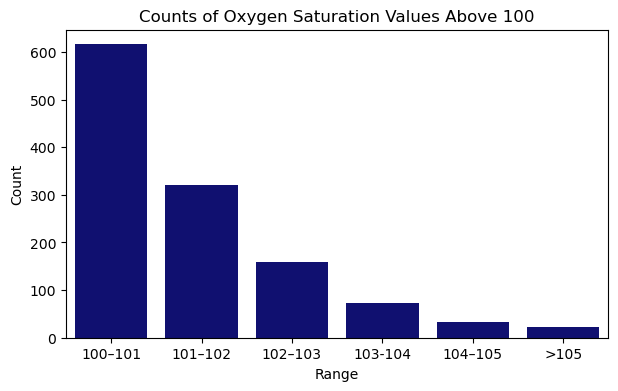

In [39]:
oxygen_bins = train_df["Oxygen Saturation"]

bins = [100, 101, 102, 103,104, 105, oxygen_bins.max()]
labels = ["100–101","101–102","102–103","103-104","104–105",">105"]

ox_ranges = pd.cut(oxygen_bins[oxygen_bins > 100], bins=bins, labels=labels)

count_data = ox_ranges.value_counts().sort_index()

plt.figure(figsize=(7,4))
sns.barplot(x=count_data.index, y=count_data.values,color='navy')
plt.title("Counts of Oxygen Saturation Values Above 100")
plt.ylabel("Count")
plt.xlabel("Range")
plt.show()


since the vast majority of the values >100 are tiny errors (100–102) 100.01,100.02,etc. we will cap them at 100 instead of dropping.

but for higher values we drop them separately

In [40]:
print("Before cleaning, total rows:", len(train_df))
print("Oxygen Saturation >100 count:", (train_df['Oxygen Saturation'] > 100).sum())

Before cleaning, total rows: 20058
Oxygen Saturation >100 count: 1223


In [41]:
#cap minor deviations at 100
train_df.loc[(train_df['Oxygen Saturation'] > 100) & (train_df['Oxygen Saturation'] <= 103), 'Oxygen Saturation'] = 100

#we drop the rest (>103)
train_df = train_df[train_df['Oxygen Saturation'] <= 103]

In [42]:
print("After cleaning, total rows:", len(train_df))
print("Oxygen Saturation >100 count:", (train_df['Oxygen Saturation'] > 100).sum())

After cleaning, total rows: 19930
Oxygen Saturation >100 count: 0


### Observing correlation between all numerical features

There isn't a very strong correlation between features, meaning we dont need to drop one a feature due to high correlation reason

the highest correlation is 0.6, which is between glucose and HbA1c, though not high enough to the point where we need to drop it
As we've seen previously, both glucose and HbA1c tend to be high for people with diabetes, which explains why it is showing a strong correlation here

0.5 for physical activiy and diet score

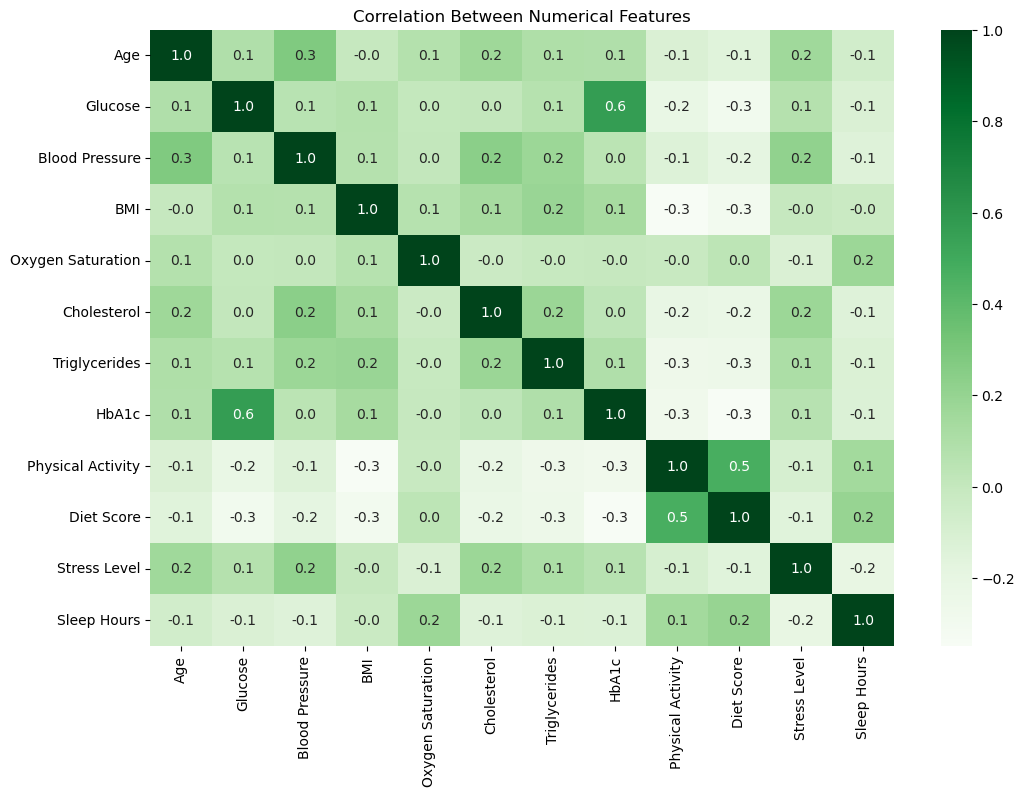

In [43]:
numerical_columns = ['Age','Glucose','Blood Pressure','BMI','Oxygen Saturation','Cholesterol','Triglycerides','HbA1c','Physical Activity','Diet Score','Stress Level','Sleep Hours']

plt.figure(figsize=(12,8))
sns.heatmap(train_df[numerical_columns].corr(),annot=True, cmap='Greens', fmt='.1f')
plt.title('Correlation Between Numerical Features')
plt.show()

# Training Models


the model is doing good overall, however, due to imbalanced classes, it is failing to classify rare classes.
the model gives high preciison,recall for high classes like (hypertension,diabetes), and low recall for small classes like cancer and arthitis

In [44]:
X_train = train_df.drop('Medical Condition', axis=1)
y_train = train_df['Medical Condition']

X_test = test_df.drop('Medical Condition', axis=1)
y_test = test_df['Medical Condition']

In [45]:
#encoding the gender column 
gender_le = LabelEncoder()
X_train['Gender'] = pd.Series(gender_le.fit_transform(X_train['Gender']), index=X_train.index)
X_test['Gender']  = pd.Series(gender_le.transform(X_test['Gender']), index=X_test.index)

#encoding the target column
target_le = LabelEncoder()
y_train = pd.Series(target_le.fit_transform(y_train), index=y_train.index)
y_test  = pd.Series(target_le.transform(y_test), index=y_test.index)

In [46]:
print("Train shape:", X_train.shape)
print("\nTest shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

Train shape: (19930, 16)

Test shape: (5100, 16)

Training class distribution:
5    5634
3    4944
6    2959
4    2421
1    1605
0    1406
2     961
Name: count, dtype: int64


## Feature Selection


    K = 2
LogisticRegression  | Accuracy = 0.4559
RandomForest  | Accuracy = 0.4678
CatBoost  | Accuracy = 0.5433

    K = 4
LogisticRegression  | Accuracy = 0.5702
RandomForest  | Accuracy = 0.6720
CatBoost  | Accuracy = 0.6829

    K = 6
LogisticRegression  | Accuracy = 0.7198
RandomForest  | Accuracy = 0.7861
CatBoost  | Accuracy = 0.7914

    K = 8
LogisticRegression  | Accuracy = 0.7676
RandomForest  | Accuracy = 0.8292
CatBoost  | Accuracy = 0.8341

    K = 10
LogisticRegression  | Accuracy = 0.7869
RandomForest  | Accuracy = 0.8578
CatBoost  | Accuracy = 0.8614

    K = 12
LogisticRegression  | Accuracy = 0.7916
RandomForest  | Accuracy = 0.8637
CatBoost  | Accuracy = 0.8747

    K = 14
LogisticRegression  | Accuracy = 0.7908
RandomForest  | Accuracy = 0.8673
CatBoost  | Accuracy = 0.8771

    K = 16
LogisticRegression  | Accuracy = 0.7904
RandomForest  | Accuracy = 0.8639
CatBoost  | Accuracy = 0.8788


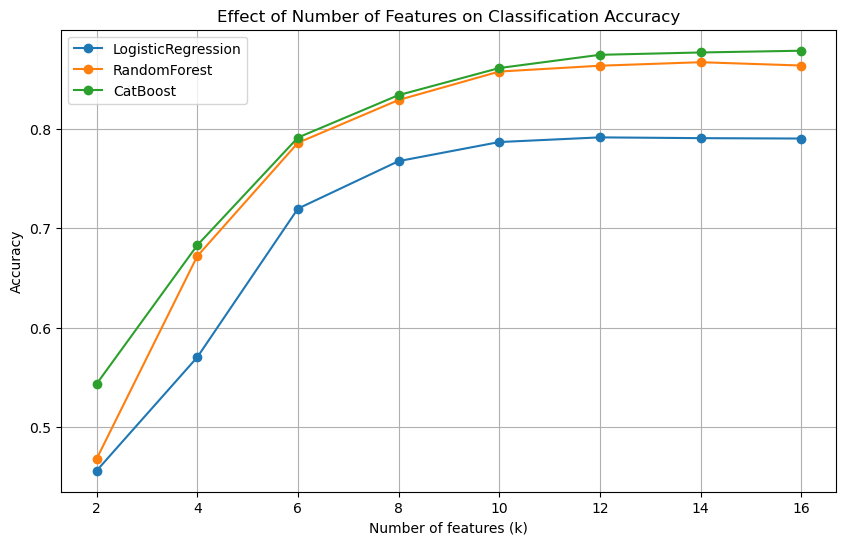

In [51]:
# Models to evaluate
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(iterations=300, verbose=0)
}

# Total number of features
num_features = X_train.shape[1]    # should be 16

k_values = list(range(2, num_features + 1, 2)) 

# Save accuracy results
results_acc = {name: [] for name in models.keys()}

for k in k_values:
    print(f"\n    K = {k}")
    
    #Feature selection on train set
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    #Train&evaluate each model
    for name, model in models.items():
        model.fit(X_train_k, y_train)
        y_pred = model.predict(X_test_k)
        acc = accuracy_score(y_test, y_pred)
        
        results_acc[name].append(acc)
        print(f"{name}  | Accuracy = {acc:.4f}")


# Plot curves
plt.figure(figsize=(10,6))
for name, scores in results_acc.items():
    plt.plot(k_values, scores, marker='o', label=name)

plt.xlabel('Number of features (k)')
plt.ylabel('Accuracy')
plt.title('Effect of Number of Features on Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [52]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

k = 12  #chosen number of features

selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_train, y_train)

#selected feature names
top_features = X_train.columns[selector.get_support()]
print("\nFinal 12 Selected Features: ")
print(top_features)

#feature scores
scores = selector.scores_
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": scores
}).sort_values(by="Score", ascending=False)

print("\n Top 12 Features (Sorted):")
print(feature_scores.head(12))



Final 12 Selected Features: 
Index(['Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
       'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
       'Diet Score', 'Stress Level', 'Sleep Hours'],
      dtype='object')

 Top 12 Features (Sorted):
              Feature     Score
8               HbA1c  0.441733
2             Glucose  0.381677
0                 Age  0.365587
11  Physical Activity  0.346922
12         Diet Score  0.311850
3      Blood Pressure  0.244455
4                 BMI  0.205636
7       Triglycerides  0.172150
6         Cholesterol  0.156481
5   Oxygen Saturation  0.147429
14       Stress Level  0.143253
15        Sleep Hours  0.140510


In [53]:
X_train_selected = selector.transform(X_train)
X_test_selected  = selector.transform(X_test)

# Logistic Regression

In [54]:
logisticReg_baseline = Pipeline([
    ("scaler", StandardScaler()),              
    ("clf", LogisticRegression(random_state=42,max_iter=2000,n_jobs=-1))
])
logisticReg_baseline.fit(X_train_selected, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(max_iter=2000, n_jobs=-1,
                                    random_state=42))])

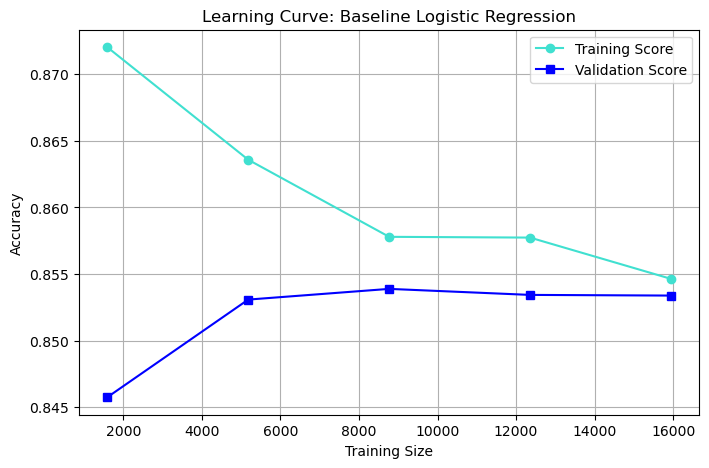

In [63]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='accuracy',      
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Training Score',color='turquoise')
    plt.plot(train_sizes, test_scores.mean(axis=1), marker='s', label='Validation Score',color='blue')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

#plotting the Logistic Regression baseline 
plot_learning_curve(logisticReg_baseline, X_train_selected, y_train, "Learning Curve: Baseline Logistic Regression")

### Tuning the Logistic Regression

In [78]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])

logistic_params = {
    'clf__C': [1, 5, 10, 50, 100, 500], 
    'clf__penalty': ['l2'],        
    'clf__solver': ['liblinear', 'saga'], 
    'clf__class_weight': [None, 'balanced']  
}

logisticReg_randomSearch = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=20,
    scoring='f1_macro',  
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#fit
logisticReg_randomSearch.fit(X_train_selected, y_train)

print("Best Parameters:", logisticReg_randomSearch.best_params_)
print("Best CV F1 Score:", logisticReg_randomSearch.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__class_weight': None, 'clf__C': 1}
Best CV F1 Score: 0.7868790546348137


In [79]:
tuned_logisticReg_model = logisticReg_randomSearch.best_estimator_

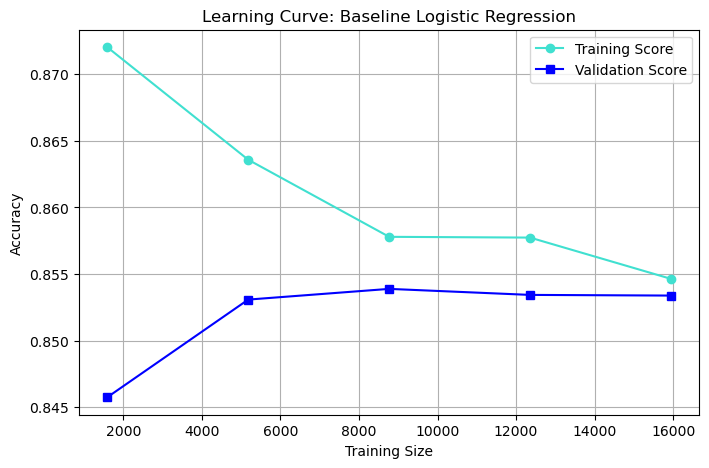

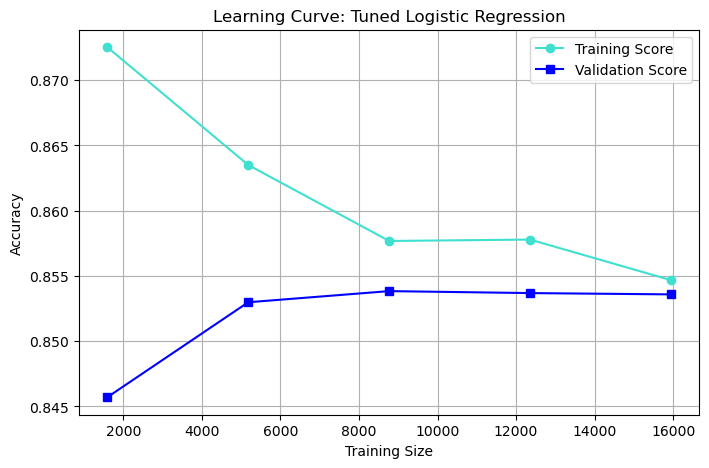

In [81]:
#plotting the Logistic Regression baseline 
plot_learning_curve(logisticReg_baseline, X_train_selected, y_train, "Learning Curve: Baseline Logistic Regression")

#plotting the tuned Logistic Regression model (tuned using randomizedSearch)
plot_learning_curve(tuned_logisticReg_model, X_train_selected, y_train, "Learning Curve: Tuned Logistic Regression")

Baseline Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.60      0.65       359
           1       0.87      0.84      0.85       407
           2       0.50      0.36      0.42       247
           3       0.93      0.92      0.93      1284
           4       0.96      0.98      0.97       608
           5       0.80      0.88      0.84      1424
           6       0.86      0.88      0.87       771

    accuracy                           0.85      5100
   macro avg       0.80      0.78      0.79      5100
weighted avg       0.85      0.85      0.85      5100



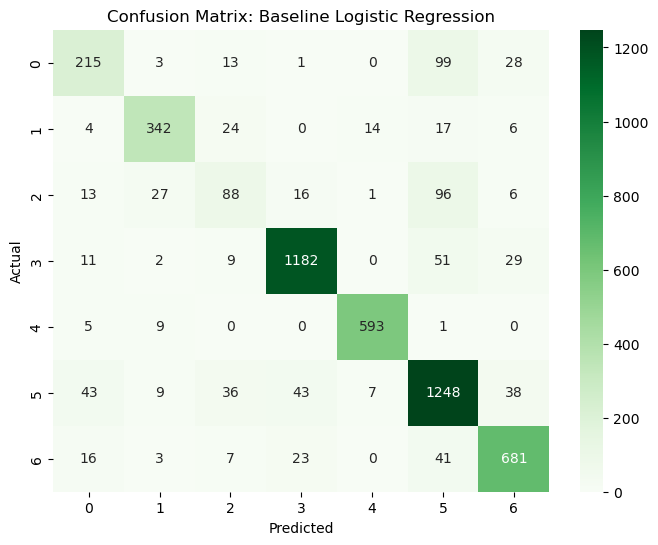

In [55]:
y_pred_logisticReg_baseline = logisticReg_baseline.predict(X_test_selected)
print("Baseline Logistic Regression")
print(classification_report(y_test, y_pred_logisticReg_baseline))

cm = confusion_matrix(y_test, y_pred_logisticReg_baseline)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=logisticReg_baseline.classes_,yticklabels=logisticReg_baseline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Baseline Logistic Regression")
plt.show()

Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.60      0.65       359
           1       0.87      0.84      0.85       407
           2       0.50      0.36      0.42       247
           3       0.93      0.92      0.93      1284
           4       0.96      0.98      0.97       608
           5       0.80      0.88      0.84      1424
           6       0.86      0.88      0.87       771

    accuracy                           0.85      5100
   macro avg       0.80      0.78      0.79      5100
weighted avg       0.85      0.85      0.85      5100



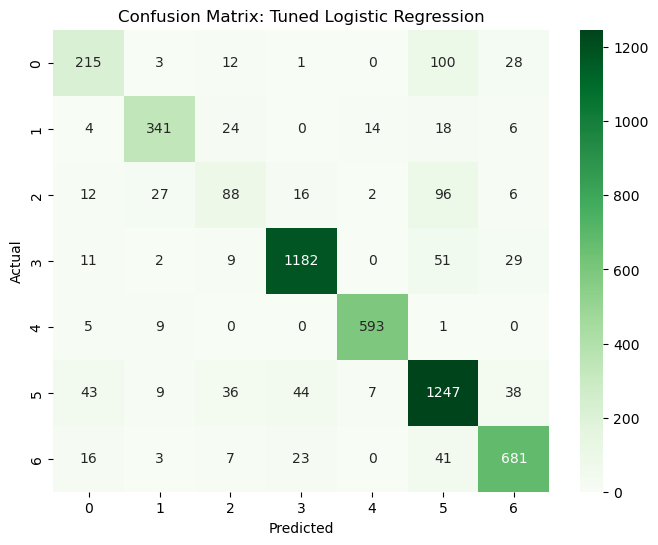

In [80]:
y_pred_logisticReg_tuned = tuned_logisticReg_model.predict(X_test_selected)
print("Tuned Logistic Regression")
print(classification_report(y_test, y_pred_logisticReg_tuned))

cm = confusion_matrix(y_test, y_pred_logisticReg_tuned)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=tuned_logisticReg_model.classes_,yticklabels=tuned_logisticReg_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Tuned Logistic Regression")
plt.show()

# Random Forest

In [84]:
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_selected, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

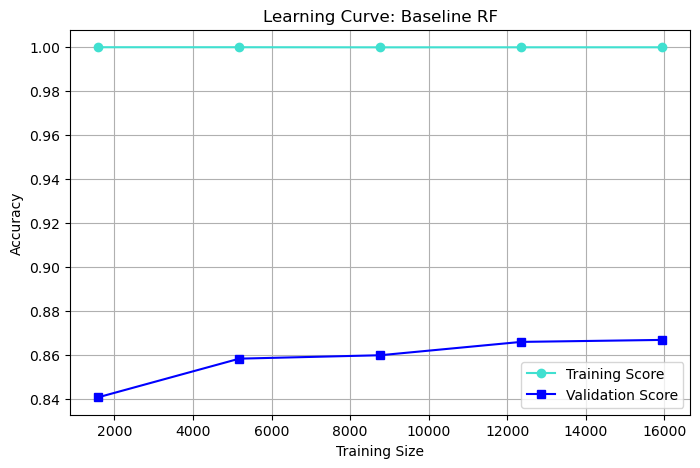

In [85]:
#plotting the rf baseline (first one)
plot_learning_curve(rf_baseline, X_train_selected, y_train, "Learning Curve: Baseline RF")

In [68]:
from sklearn.model_selection import RandomizedSearchCV

#hyperparameters 
rf_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 10, 14],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#start randomized Search
rf_randomSearch = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1), 
    param_distributions=rf_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_randomSearch.fit(X_train_selected, y_train)

print("Randomized Search Best Parameters",rf_randomSearch.best_params_)
print("Best CV F1 Score:", rf_randomSearch.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Randomized Search Best Parameters {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 14}
Best CV F1 Score: 0.7988089570815289


In [69]:
#best model
tuned_rf_model = rf_randomSearch.best_estimator_

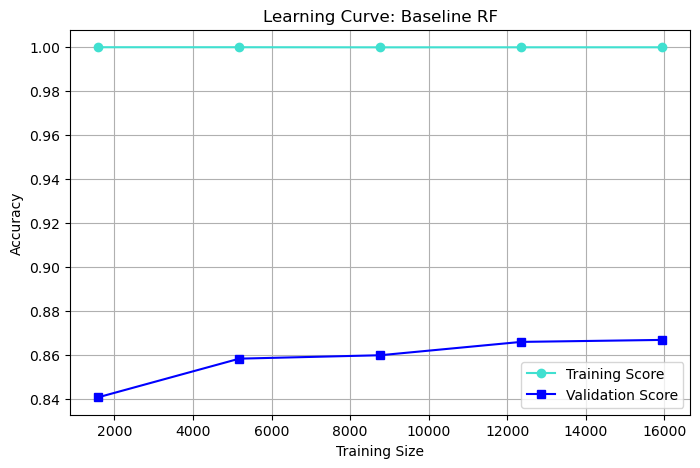

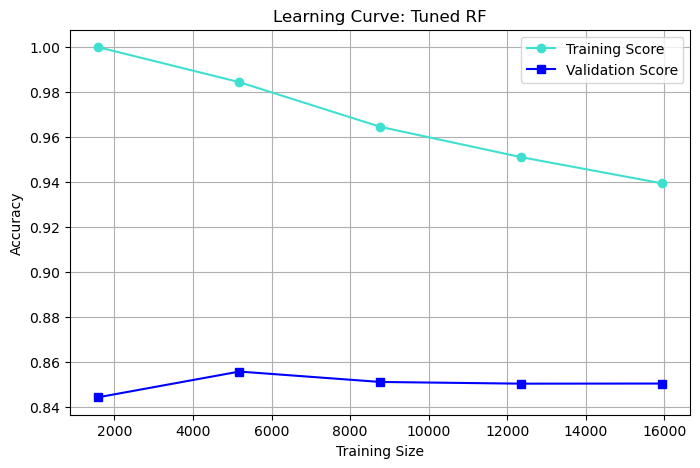

In [70]:
#plotting the rf baseline (first one)
plot_learning_curve(rf_baseline, X_train_selected, y_train, "Learning Curve: Baseline RF")

#plotting the tuned RF model (tuned using randomizedSearch)
plot_learning_curve(tuned_rf_model, X_train_selected, y_train, "Learning Curve: Tuned RF")

In [82]:
#saving the rf models

joblib.dump(rf_baseline, "rf_baseline.pkl")
joblib.dump(tuned_rf_model, "tuned_rf_model.pkl")
print("Model saved!")

Model saved!


In [83]:
#loading model

rf_baseline = joblib.load("rf_baseline.pkl")
tuned_rf_model = joblib.load("tuned_rf_model.pkl")
print("Model loaded!")

Model loaded!


Baseline RF
              precision    recall  f1-score   support

           0       0.73      0.57      0.64       359
           1       0.85      0.86      0.85       407
           2       0.65      0.30      0.41       247
           3       0.95      0.93      0.94      1284
           4       0.96      0.98      0.97       608
           5       0.80      0.92      0.86      1424
           6       0.87      0.89      0.88       771

    accuracy                           0.86      5100
   macro avg       0.83      0.78      0.79      5100
weighted avg       0.86      0.86      0.86      5100



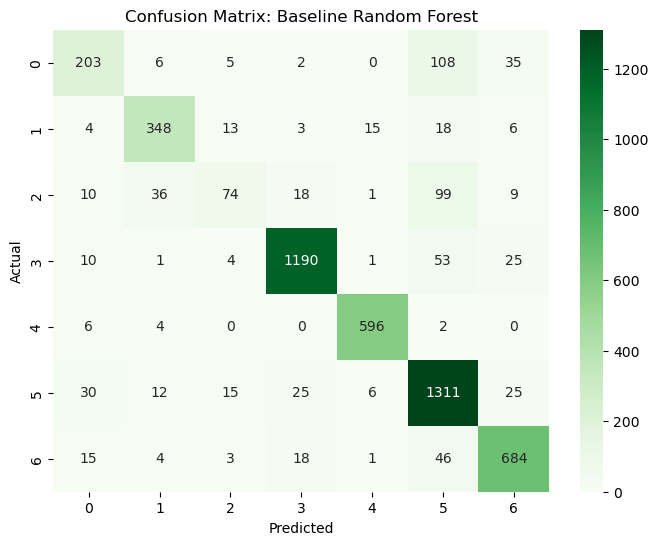

In [104]:
y_pred_baseline = rf_baseline.predict(X_test_selected)
print("Baseline RF")
print(classification_report(y_test, y_pred_baseline))

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=rf_baseline.classes_,yticklabels=rf_baseline.classes_)
plt.title("Confusion Matrix: Baseline Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Tuned RF
              precision    recall  f1-score   support

           0       0.57      0.77      0.65       359
           1       0.85      0.84      0.84       407
           2       0.45      0.53      0.48       247
           3       0.96      0.90      0.93      1284
           4       0.97      0.98      0.97       608
           5       0.88      0.82      0.85      1424
           6       0.89      0.88      0.88       771

    accuracy                           0.85      5100
   macro avg       0.79      0.82      0.80      5100
weighted avg       0.86      0.85      0.86      5100



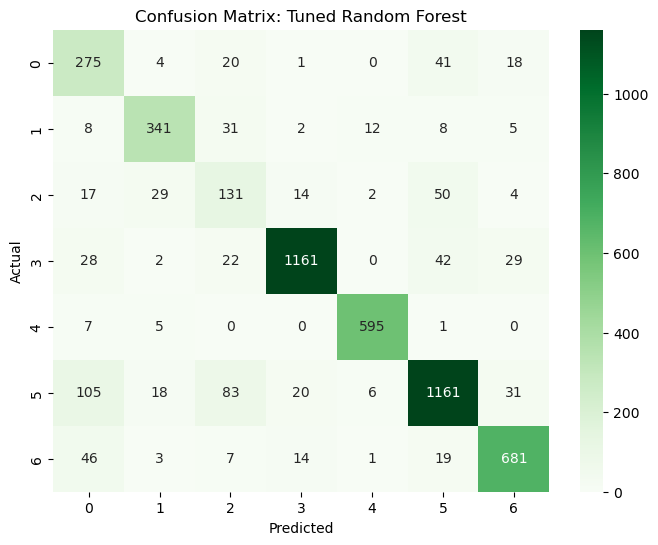

In [87]:
#evaluating tuned models
y_pred_tuned_rf = tuned_rf_model.predict(X_test_selected)
print("Tuned RF")
print(classification_report(y_test, y_pred_tuned_rf))

cm = confusion_matrix(y_test, y_pred_tuned_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=tuned_rf_model.classes_,yticklabels=tuned_rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Tuned Random Forest")
plt.show()

# CatBoost model

In [88]:
catBoost_baseline = CatBoostClassifier(verbose=0, random_state=42)
catBoost_baseline.fit(X_train_selected, y_train)

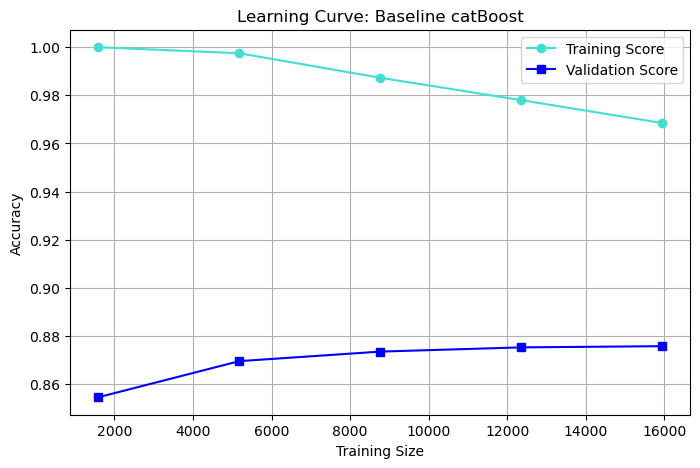

In [90]:
#plotting the catBoost baseline 
plot_learning_curve(catBoost_baseline, X_train_selected, y_train, "Learning Curve: Baseline catBoost")

### tuning the catBoost model

In [92]:
params = {
    'depth': [6, 8],
    'learning_rate': [0.01, 0.1, 0.15],
    'iterations': [200,300,1000]
}

catBoost = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

#start randomized Search
catBoost_randomSearch = RandomizedSearchCV(
    estimator=catBoost,
    param_distributions=params,
    n_iter=10,            
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

catBoost_randomSearch.fit(X_train_selected, y_train)

print("Randomized Search Best Parameters", catBoost_randomSearch.best_params_)
print("Best CV F1 Score:", catBoost_randomSearch.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Randomized Search Best Parameters {'learning_rate': 0.1, 'iterations': 200, 'depth': 6}
Best CV F1 Score: 0.8193586808366743


In [93]:
tuned_catBoost_model = catBoost_randomSearch.best_estimator_

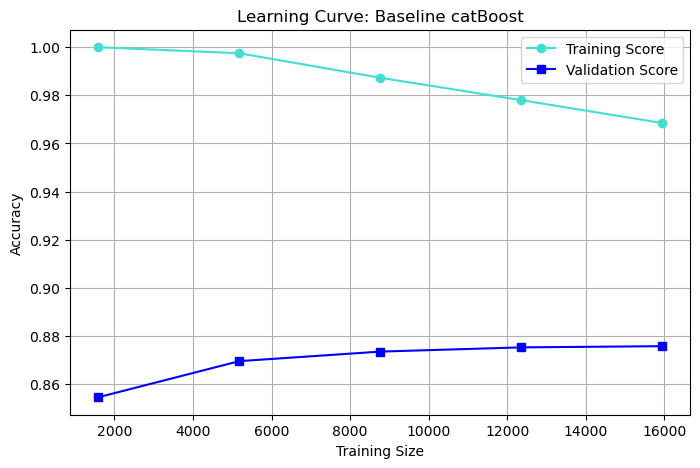

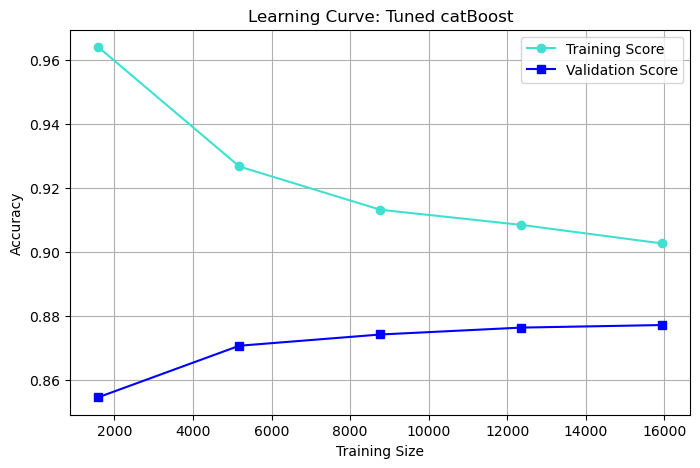

In [95]:
#plotting the catBoost baseline 
plot_learning_curve(catBoost_baseline, X_train_selected, y_train, "Learning Curve: Baseline catBoost")

#plotting the tuned catBoost model (tuned using randomizedSearch)
plot_learning_curve(tuned_catBoost_model, X_train_selected, y_train, "Learning Curve: Tuned catBoost")

Baseline CatBoost
              precision    recall  f1-score   support

           0       0.76      0.67      0.71       359
           1       0.86      0.86      0.86       407
           2       0.59      0.40      0.48       247
           3       0.94      0.94      0.94      1284
           4       0.98      0.99      0.98       608
           5       0.84      0.90      0.87      1424
           6       0.89      0.91      0.90       771

    accuracy                           0.88      5100
   macro avg       0.84      0.81      0.82      5100
weighted avg       0.87      0.88      0.88      5100



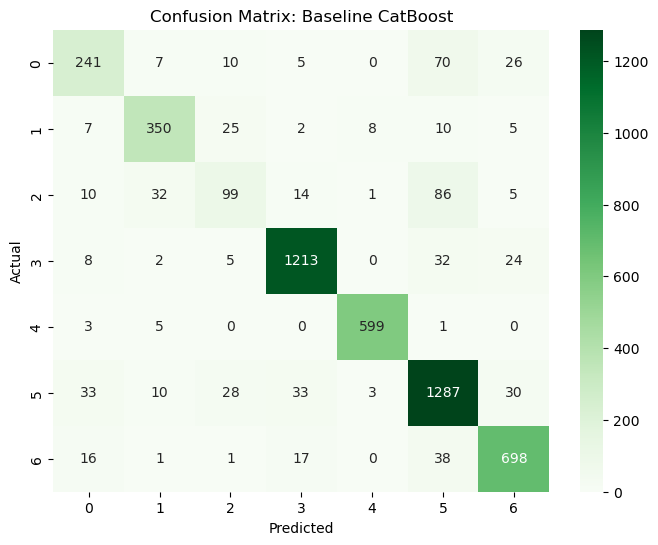

In [91]:
y_pred_cat_baseline = catBoost_baseline.predict(X_test_selected)
print("Baseline CatBoost")
print(classification_report(y_test, y_pred_cat_baseline))

cm = confusion_matrix(y_test, y_pred_cat_baseline)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=catBoost_baseline.classes_,yticklabels=catBoost_baseline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Baseline CatBoost")
plt.show()

Tuned CatBoost
              precision    recall  f1-score   support

           0       0.77      0.66      0.71       359
           1       0.88      0.87      0.88       407
           2       0.66      0.39      0.49       247
           3       0.94      0.94      0.94      1284
           4       0.97      0.98      0.98       608
           5       0.83      0.91      0.87      1424
           6       0.89      0.91      0.90       771

    accuracy                           0.88      5100
   macro avg       0.85      0.81      0.82      5100
weighted avg       0.88      0.88      0.88      5100



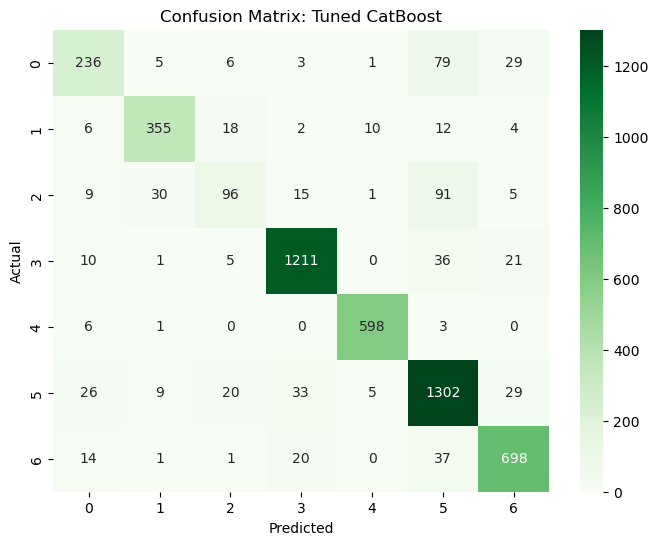

In [94]:
y_pred_cat_tuned = tuned_catBoost_model.predict(X_test_selected)
print("Tuned CatBoost")
print(classification_report(y_test, y_pred_cat_tuned))

cm = confusion_matrix(y_test, y_pred_cat_tuned)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=tuned_catBoost_model.classes_,yticklabels=tuned_catBoost_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Tuned CatBoost")
plt.show()

# Plotting Test Curve

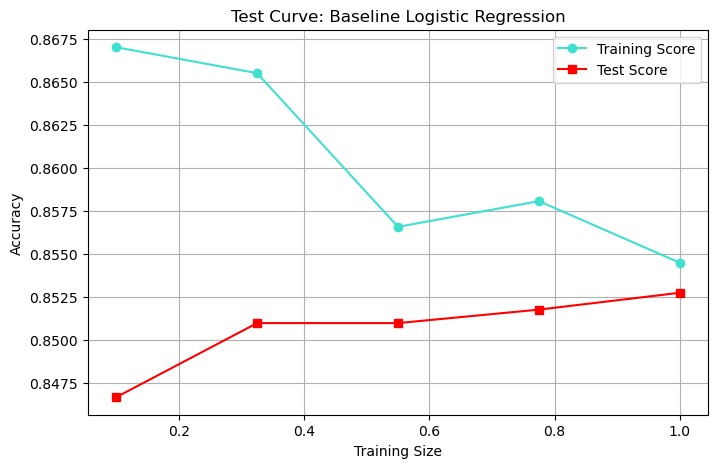

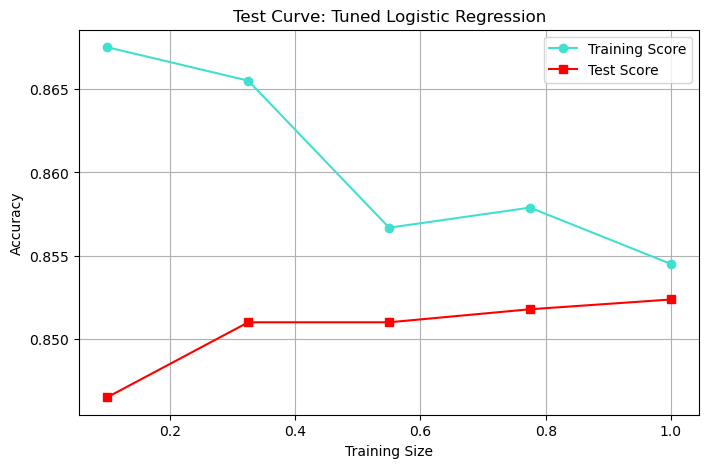

In [101]:
def plot_test_curve(model, X_train_selected, y_train, X_test_selected, y_test, title):
    
    train_sizes = np.linspace(0.1, 1.0, 5)

    train_scores = []
    test_scores = []

    for size in train_sizes:

        #take subset of train
        n = int(size * len(X_train_selected))
        X_sub = X_train_selected[:n]
        y_sub = y_train[:n]

        # train model on subset
        model.fit(X_sub, y_sub)

        #evaluate on train set
        y_train_pred = model.predict(X_sub)
        train_scores.append(accuracy_score(y_sub, y_train_pred))

        #evaluate on test set
        y_test_pred = model.predict(X_test_selected)
        test_scores.append(accuracy_score(y_test, y_test_pred))

    #plot
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores, marker='o', label='Training Score', color='turquoise')
    plt.plot(train_sizes, test_scores, marker='s', label='Test Score', color='red')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_test_curve(logisticReg_baseline, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Baseline Logistic Regression")
plot_test_curve(tuned_logisticReg_model, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Tuned Logistic Regression")

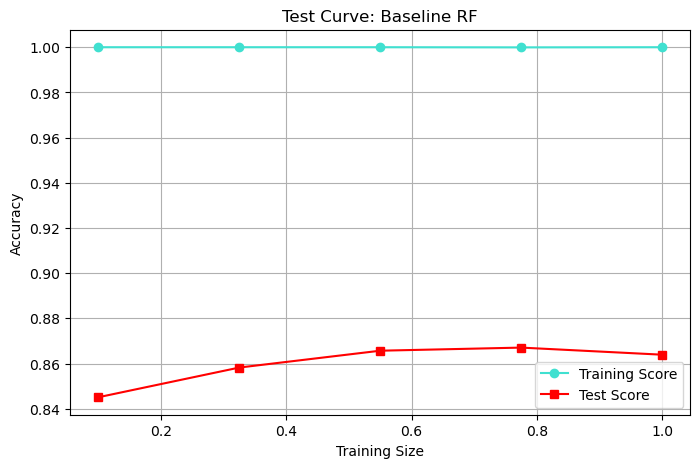

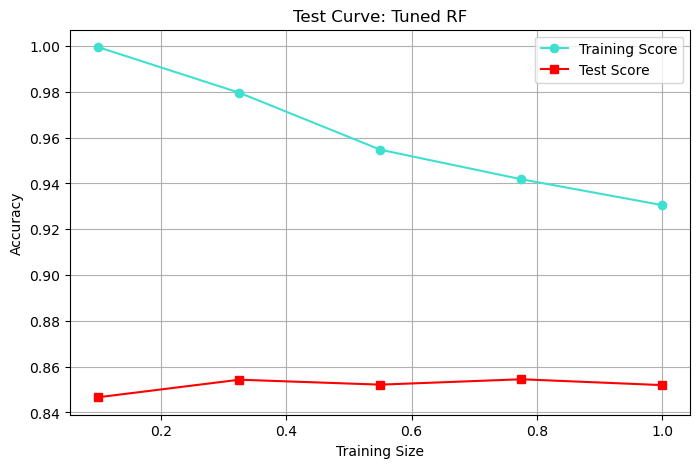

In [102]:

plot_test_curve(rf_baseline, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Baseline RF")
plot_test_curve(tuned_rf_model, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Tuned RF")

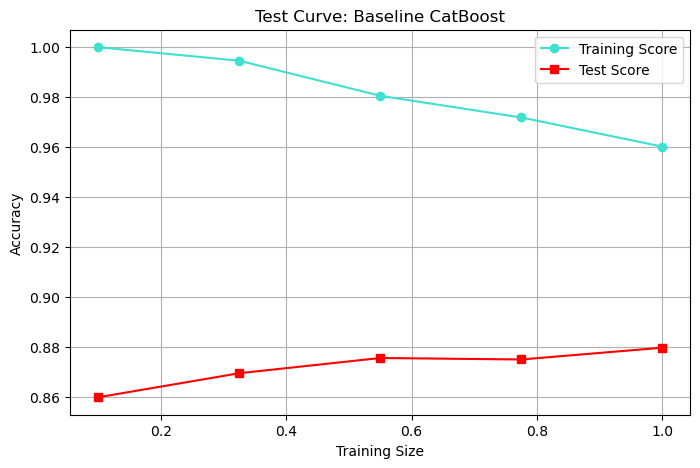

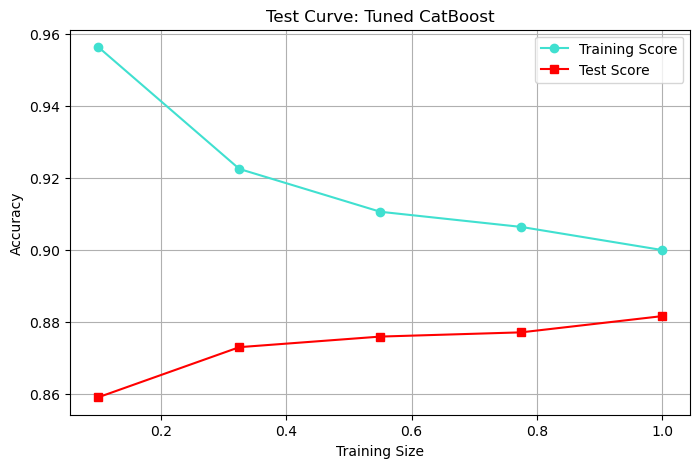

In [103]:

plot_test_curve(catBoost_baseline, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Baseline CatBoost")
plot_test_curve(tuned_catBoost_model, X_train_selected, y_train, X_test_selected, y_test, "Test Curve: Tuned CatBoost")
